Overall Accuracy: 100.00%
Patient 1: Actual: Yes, Predicted: Yes
Patient 2: Actual: Yes, Predicted: Yes


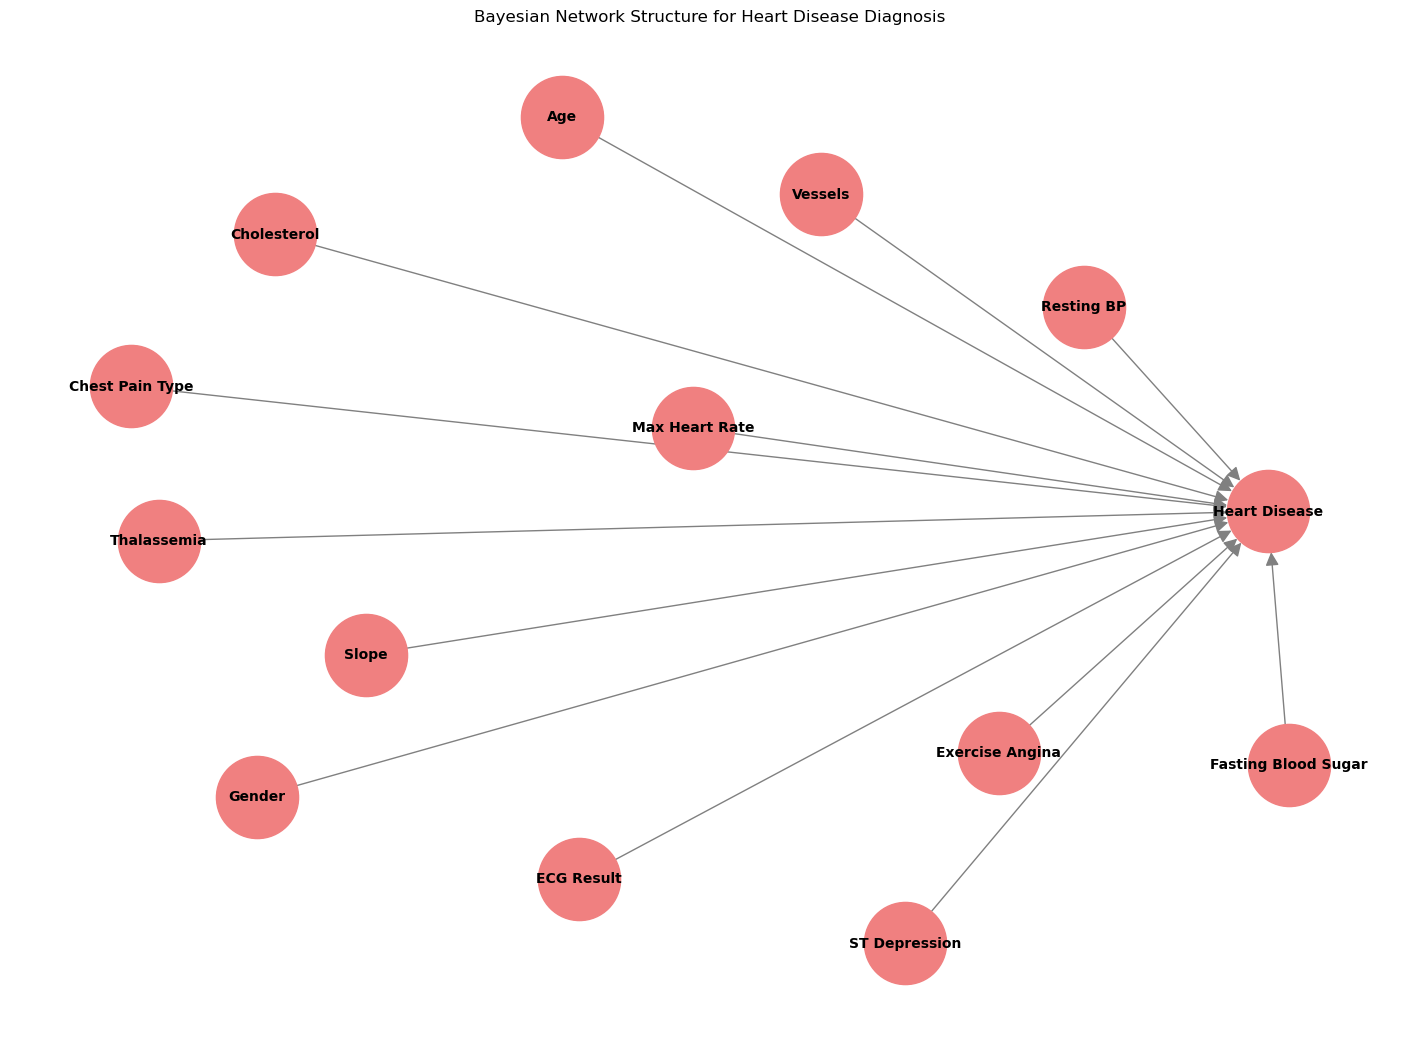

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('Heart.csv')

target = 'Heart Disease'
num_cols = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
cat_cols = [c for c in df.columns if c not in num_cols and c != target]

le_dict = {}
for col in cat_cols + [target]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
df[num_cols] = kbd.fit_transform(df[num_cols]).astype(int)

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CategoricalNB(min_categories=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy * 100:.2f}%")

demo_indices = [0, 1]
for idx in demo_indices:
    actual = "Yes" if y_test.iloc[idx] == 1 else "No"
    pred = "Yes" if y_pred[idx] == 1 else "No"
    print(f"Patient {idx+1}: Actual: {actual}, Predicted: {pred}")

G = nx.DiGraph()
for col in X.columns:
    G.add_edge(col, target)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)
nx.draw(G, pos, with_labels=True, node_size=3500, node_color='lightcoral',
        font_size=10, font_weight='bold', arrowsize=20, edge_color='gray')
plt.title("Bayesian Network Structure for Heart Disease Diagnosis")
plt.savefig('heart_disease_network.png')
plt.show()